# 00. DECam Streak List Data Analysis
Written by Kiyoaki Okudaira<br>
*University of Washington / Kyushu University / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
Analyze and clean decam streak list data by exposure counts, trail length, and availability to download image data from noirlab etc.<br>
<br>
**History**<br>
coding 2025-10-26 : 1st coding<br>
update 2025-10-27 : Plot histogram of width and height of trails and mask (in the meeting with Meredith & Dino)<br>
update 2025-11-02 : Cleaned up error streak records by counts of detecters in each exposure & Check availability of image data at noirlab<br>
update 2025-11-03 : Cleaned up records by observation year and example of random rows pick-up (in the meeting with Meredith & Dino)<br>
update 2026-05-02 : Output filename changed

### Initial Settings
**Libraries**

In [ ]:
# Standard libraries
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import json
from os import path

# Public libraries
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
from astropy.time import Time
from tqdm.notebook import tqdm

# Custom libraries
import satphotometry as sp 

**Import file settings**

In [ ]:
# project directory
PATH_project = '/astro/store/shire/kiyoaki/ASTR499/'

PATH_input   = PATH_project + 'input/'
PATH_output  = PATH_project + 'output/'

PATH_image   = PATH_input  + 'fits_data/'
PATH_session = PATH_output + 'session/'

# ORIGINAL streak list from Alex
fname_streak_list = 'streaks_augmented_20230817.csv'
PATH_streak_list  = fname_streak_list + 'decam_streak_list/' + fname_streak_list

### Part 1 : Length of Streak
Calculate length of streak from 4 corners' RA/DEC information

In [ ]:
# Error handling for missing value
def to_float_or_none(s):
    if s is None:
        return None
    s = s.strip()
    if s == "" or s.lower() == "nan":
        return None
    try:
        return float(s)
    except ValueError:
        return None

rows_out = []

with open(PATH_streak_list, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames

    out_fieldnames = fieldnames + ["width", "height", "area"]

    for row in tqdm(reader):
        ra = [to_float_or_none(row.get(f"ra_{i}")) for i in range(1, 5)]
        dec = [to_float_or_none(row.get(f"dec_{i}")) for i in range(1, 5)]

        if None in ra or None in dec:
            row["width"] = ""
            row["height"] = ""
            row["area"] = ""
            rows_out.append(row)
            continue

        # Skycord convertion
        c1 = SkyCoord(ra[0]*u.deg, dec[0]*u.deg)
        c2 = SkyCoord(ra[1]*u.deg, dec[1]*u.deg)
        c3 = SkyCoord(ra[2]*u.deg, dec[2]*u.deg)
        c4 = SkyCoord(ra[3]*u.deg, dec[3]*u.deg)

        # Calculate length between points
        d12 = c1.separation(c2).to(u.arcsec).value
        d13 = c1.separation(c3).to(u.arcsec).value
        d14 = c1.separation(c4).to(u.arcsec).value

        # Sort length and the shortest one should be width, and the second shortest one should be height
        dists = sorted([d12, d13, d14])
        width = dists[0]
        height = dists[1]
        area = width * height

        # Write trail length and area in the list
        row["width"] = f"{width:.6f}"
        row["height"] = f"{height:.6f}"
        row["area"] = f"{area:.6f}"

        rows_out.append(row)
        # print(row["expnum"],row["width"],row["height"],row["area"])

In [ ]:
# Output result
with open(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_wha.csv', "w", encoding="utf-8", newline="") as fo:
    writer = csv.DictWriter(fo, fieldnames=out_fieldnames)
    writer.writeheader()
    for r in rows_out:
        writer.writerow(r)

### Part 2 : How many detecters with same EXPNUM captured streaks
Read CSV

In [ ]:
data = []
with open(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_wha.csv', "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    
    for row in reader:
        record = {}
        for key, value in row.items():
            if key in ["filename", "band"]:
                record[key] = value
            elif key in ["rnum", "ccdnum", "expnum"]:
                record[key] = int(value)
            else:
                try:
                    record[key] = float(value)
                except ValueError:
                    record[key] = float("nan")
        data.append(record)

Count records with each EXPNUM

In [ ]:
expnum_counts = defaultdict(int)
for record in data:
    expnum_counts[record["expnum"]] += 1

with open(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_expnumCount.csv', "w", encoding="utf-8", newline="") as fo:
    writer = csv.writer(fo)
    writer.writerow(["expnum", "record_count"])

    for expnum in sorted(expnum_counts.keys()):
        writer.writerow([expnum, expnum_counts[expnum]])

Plot histogram of streak count with each EXPNUM

In [ ]:
streak_counts = Table.read(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_expnumCount.csv')
streak_counts

expnum,record_count
int64,int64
145425,24
145427,1
145428,2
145429,3
145431,1
145432,4
145433,3
145434,10
145500,14


Plot histogram of streak counts

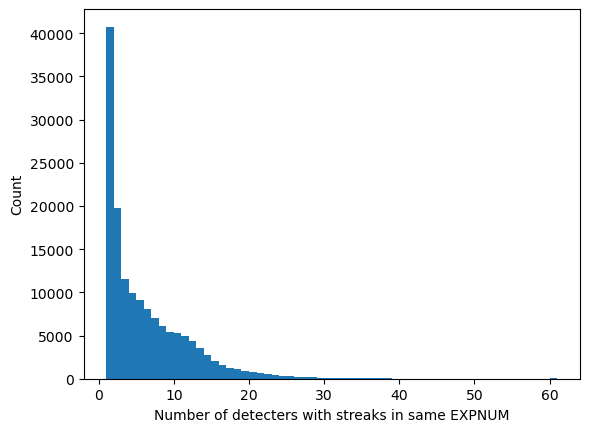

In [13]:
plt.hist(streak_counts["record_count"],bins="auto")
plt.xlabel("Number of detecters with streaks in same EXPNUM")
plt.ylabel("Count")
plt.show()

Delete rows which are supposed to be error counts (record counts more than 32 (half of detecters))

In [ ]:
mask = streak_counts["record_count"] > 32
error_streak_counts = streak_counts[mask]

data = Table.read(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_wha.csv')
cleaned_data = data
for f in error_streak_counts["expnum"]:
    mask = cleaned_data["expnum"] == f
    cleaned_data = cleaned_data[~mask]

### Part 3 : Clean data by length of trail
Calculate trail length from RADEC information in CSV

In [11]:
data = cleaned_data
del cleaned_data

Clean data by trail width

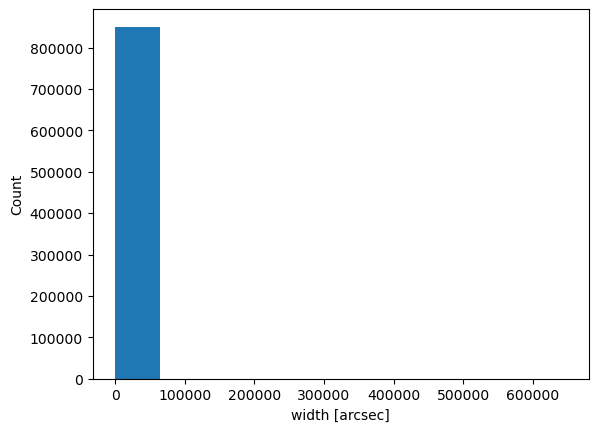

1071


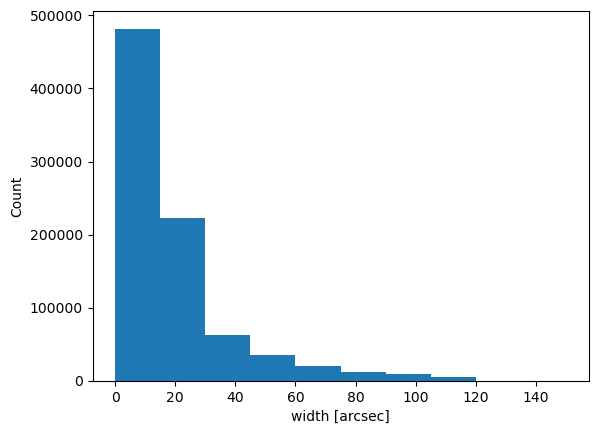

In [16]:
plt.hist(data["width"])
plt.xlabel("width [arcsec]")
plt.ylabel("Count")
plt.show()
mask = data["width"] > 150
print(mask.sum())
cleaned_data = data[~mask]
plt.hist(cleaned_data["width"])
plt.xlabel("width [arcsec]")
plt.ylabel("Count")
plt.show()

Clean data by trail height

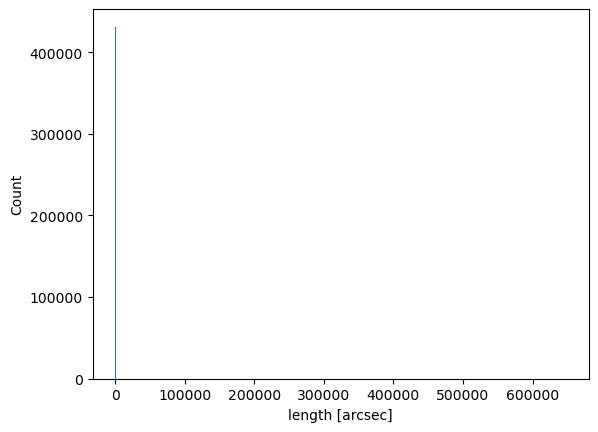

2294


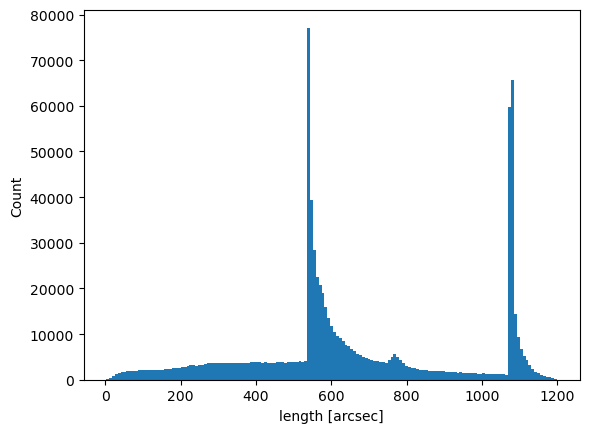

In [18]:
plt.hist(data["height"],bins="auto")
plt.xlabel("length [arcsec]")
plt.ylabel("Count")
plt.show()
mask = data["height"] > 1200
notz = data["height"] > 2
print(mask.sum())
cleaned_data = data[~mask & notz]
plt.xlabel("length [arcsec]")
plt.ylabel("Count")
plt.hist(cleaned_data["height"],bins="auto")
plt.show()

Save cleared data as csv

In [ ]:
print(len(cleaned_data))
cleaned_data.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_masked_by_wha.csv',overwrite=True)

839349


### Part 4 : Retrieve image metadata from noirlab API
Check if the image data listed is available in noirlab or not.<br>
In addition, get airmass and seeing information if available.

Read CSV and make new columns

In [ ]:
data = Table.read(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_masked_by_wha.csv')
data["archive_filename"] = "".center(256)
data["filesize"]         = 0
data["dateobs_center"]   = "".center(256)
data["dateobs_min"]      = "".center(256)
data["dateobs_max"]      = "".center(256)
data["airmass"]          = 0.0
data["seeing"]           = 0.0
data["magzero"]          = 0.0
data["img_availability"] = False
data["md5sum"]           = "".center(256)
data[-1]

filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum
str38,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str2,float64,float64,float64,str256,int64,str256,str256,str256,float64,float64,float64,bool,str256
D01223535_g_c59_r6224p01_hstreak.fits,1,323.87833,323.890982,323.836373,323.823717,-19.20354,-19.21487,-19.269001,-19.257671,1223535,59,g,59.275899,269.138913,15953.451056,,0,,,,0.0,0.0,0.0,False,


Make list of EXPNUM

Retrieve metadata from noirlab Astrodata Archive

In [ ]:
query_result = sp.noirlab.retrieve_infos(int(data["expnum"].min()),int(data["expnum"].max()))
with open(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_noirlab_metadata.json','w') as metadata_backup:
    json.dump(query_result, metadata_backup, ensure_ascii=False, indent=4, sort_keys=True, separators=(',', ': '))

Parse query result

In [ ]:
query_result = json.load(open(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_noirlab_metadata.json', 'r'))
expnums = [f["EXPNUM"] for f in query_result]

Write metadata into streaks list

In [ ]:
from tqdm import tqdm

expnums_set = set(expnums)

best_query_by_expnum = {}
for d in query_result:
    expnum = d["EXPNUM"]

    if expnum not in best_query_by_expnum:
        best_query_by_expnum[expnum] = d
    else:
        current_best = best_query_by_expnum[expnum]

        if current_best["MAGZERO"] is None and d["MAGZERO"] is not None:
            best_query_by_expnum[expnum] = d

for row in tqdm(data, desc="Writing metadata into list"):
    row_expnum = row["expnum"]

    if row_expnum not in expnums_set:
        continue

    q = best_query_by_expnum.get(row_expnum)
    if q is None:
        continue

    row["archive_filename"] = q["archive_filename"] if q["archive_filename"] is not None else ""
    row["filesize"]         = q["filesize"] if q["filesize"] is not None else ""
    row["dateobs_center"]   = q["dateobs_center"] if q["dateobs_center"] is not None else ""
    row["dateobs_min"]      = q["dateobs_min"] if q["dateobs_min"] is not None else ""
    row["dateobs_max"]      = q["dateobs_max"] if q["dateobs_max"] is not None else ""
    row["airmass"]          = float(q["AIRMASS"]) if q["AIRMASS"] is not None else 0
    row["seeing"]           = float(q["SEEING"]) if q["SEEING"] is not None else 0
    row["magzero"]          = float(q["MAGZERO"]) if q["MAGZERO"] is not None else 0

    if q["md5sum"] is not None:
        row["img_availability"] = True
        row["md5sum"] = q["md5sum"]
    else:
        row["img_availability"] = False
        row["md5sum"] = ""

data.write(
    PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_masked_by_wha.csv',
    overwrite=True
)

data

Writing metadata into list: 100%|██████████| 839349/839349 [00:18<00:00, 45980.70it/s]


filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum
str38,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str2,float64,float64,float64,str256,int64,str256,str256,str256,float64,float64,float64,bool,str256
D00145425_g_c03_r4148p01_hstreak.fits,3,1.15933,1.160919,1.16431,1.16272,-28.724241,-28.724212,-28.857155,-28.857183,145425,3,g,5.017551,478.710694,2401.955395,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c06_r4148p01_hstreak.fits,1,0.986677,0.986711,0.644209,0.644186,-29.032018,-29.034283,-29.037208,-29.034944,145425,6,g,8.154702,1078.07936,8791.416206,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c09_r4148p01_hstreak.fits,1,0.452852,0.452942,0.109842,0.109782,-29.193042,-29.199694,-29.203265,-29.196615,145425,9,g,23.94887,1078.23488,25822.507198,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c15_r4148p01_hstreak.fits,1,0.286716,0.286812,0.630816,0.630741,-29.363308,-29.358405,-29.362739,-29.367644,145425,15,g,17.65337,1079.468216,19056.251641,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c16_r4148p01_hstreak.fits,1,0.985852,0.987446,0.987211,0.985615,-29.216748,-29.216752,-29.366385,-29.366381,145425,16,g,5.008378,538.679314,2697.909686,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c24_r4148p01_hstreak.fits,1,1.358196,1.35824,1.701298,1.701272,-29.52798,-29.522197,-29.524154,-29.529931,145425,24,g,20.819256,1074.668412,22373.797056,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c26_r4148p01_hstreak.fits,2,0.094116,0.094174,359.750567,359.750533,-29.543142,-29.549807,-29.551971,-29.545314,145425,26,g,23.994688,1076.099449,25820.670082,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c27_r4148p01_hstreak.fits,1,0.105963,0.106224,0.451246,0.451014,-29.691525,-29.683101,-29.690716,-29.699147,145425,27,g,30.337383,1079.398335,32746.121156,,0,,,,0.0,0.0,0.0,False,
D00145425_g_c28_r4148p01_hstreak.fits,2,0.809661,0.809805,0.464873,0.464759,-29.542865,-29.550414,-29.554879,-29.54733,145425,28,g,27.180142,1080.312325,29363.042088,,0,,,,0.0,0.0,0.0,False,


Mask downloadable images

In [44]:
mask = data["img_availability"] == True
print("Image data available :",sum(mask))
cleaned_data = data[mask]

Image data available : 832466


Zeropoint data available : 826179


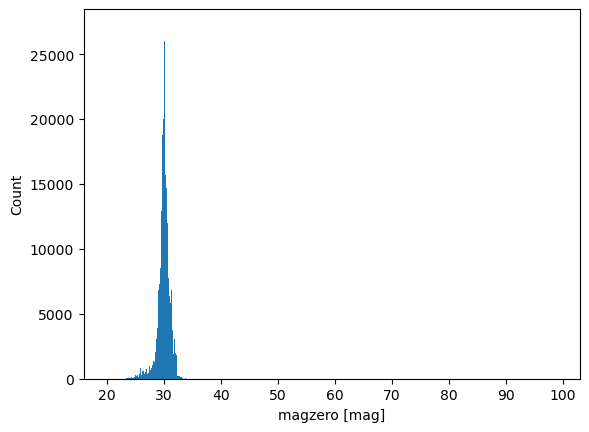

In [47]:
magzero_mask  = cleaned_data["magzero"] == 0
print("Zeropoint data available :",sum(mask)-sum(magzero_mask))
plt.hist(cleaned_data[~magzero_mask]["magzero"],bins="auto")
plt.xlabel("magzero [mag]")
plt.ylabel("Count")
plt.show()

Histogram of airmass and seeing

Airmass data available : 814811
Seeing data available  : 163610


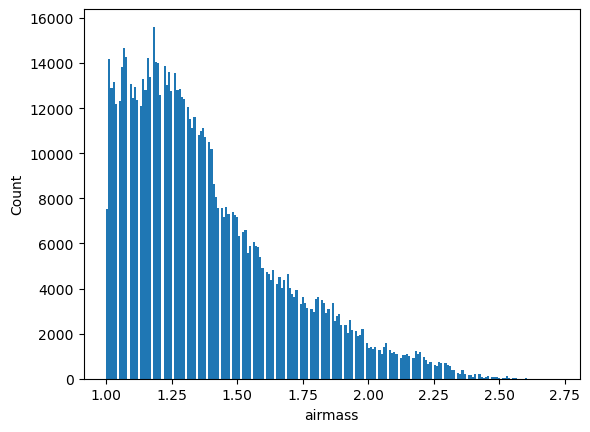

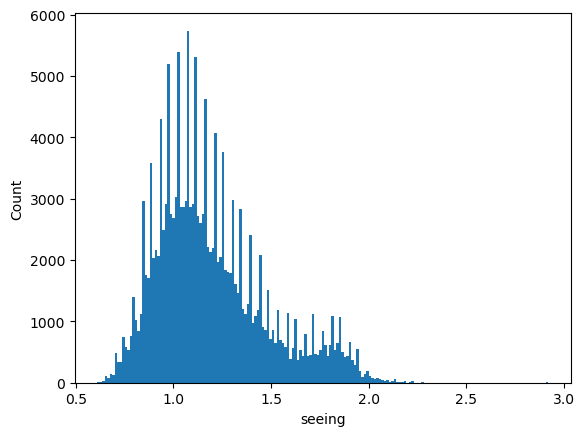

In [46]:
airmass_mask  = cleaned_data["airmass"] == 0
seeing_mask = cleaned_data["seeing"] == 0
print("Airmass data available :",sum(mask)-sum(airmass_mask))
print("Seeing data available  :",sum(mask)-sum(seeing_mask))

plt.hist(cleaned_data[~airmass_mask]["airmass"],bins="auto")
plt.xlabel("airmass")
plt.ylabel("Count")
plt.show()

plt.hist(cleaned_data[~seeing_mask]["seeing"],bins="auto")
plt.xlabel("seeing")
plt.ylabel("Count")
plt.show()

Histogram of year

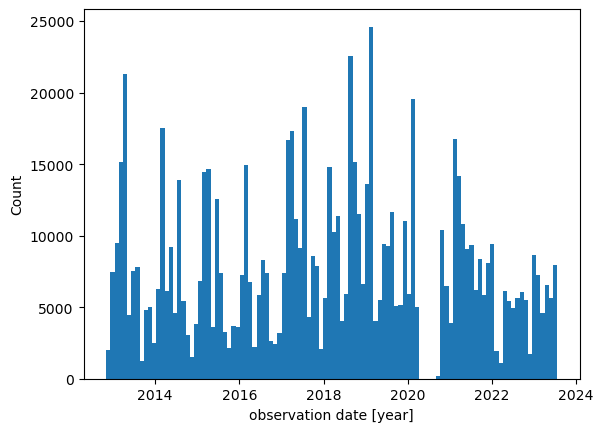

In [49]:
from datetime import datetime as dt
year = []
for row in cleaned_data:
    obs_dt = dt.strptime(row["dateobs_center"][:19],'%Y-%m-%dT%H:%M:%S')
    year.append(obs_dt.year + (int(dt.strftime(obs_dt,'%j'))-1) / (int(dt.strftime(dt.strptime(str(obs_dt.year)+"-12-31",'%Y-%m-%d'),'%j'))))
plt.hist(year,bins="auto")
plt.xlabel("observation date [year]")
plt.ylabel("Count")
plt.show()

Cleaned image by date (AFTER 2019 : Starlink operation)

In [50]:
times = Time(cleaned_data["dateobs_center"])
mask = times >= Time("2019-01-01")
cleaned_data = cleaned_data[mask]

In [ ]:
cleaned_data.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_masked_by_year.csv',overwrite=True)

### Appendix 1 : File size and group by orignal filename
The streaks list include some rows with same orignal filename. This is because some images contain multiple streaks.<br>
Grouping by unique orignal filename, calculate total filesize of images in cleaned data.

In [52]:
cleaned_data = cleaned_data.group_by("archive_filename")
sizes = [g[0]["filesize"] for g in cleaned_data.groups]
cleaned_data.groups[1]

filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum
str38,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str2,float64,float64,float64,str256,int64,str256,str256,str256,float64,float64,float64,bool,str256
D00807896_r_c54_r5801p01_streak.fits,1,9.044114,9.036551,9.056178,9.063667,-75.841835,-75.841778,-75.692204,-75.69226,807896,54,r,6.662835,538.748041,3589.589102,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012832_ooi_r_ls9.fits.fz,327804480,2019-01-01T01:29:22.243736Z,,,1.54,0.0,30.192,True,a5c7bfe1a63ed191f46402c770fa4a4a
D00807896_r_c58_r5801p01_hstreak.fits,1,9.033704,9.043058,9.022589,9.013142,-75.856328,-75.8564,-76.005745,-76.005673,807896,58,r,8.232542,537.943033,4428.638552,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012832_ooi_r_ls9.fits.fz,327804480,2019-01-01T01:29:22.243736Z,,,1.54,0.0,30.192,True,a5c7bfe1a63ed191f46402c770fa4a4a
D00807896_r_c62_r5801p01_hstreak.fits,1,9.012905,9.018726,8.997288,8.991408,-76.020423,-76.020469,-76.169649,-76.169603,807896,62,r,5.06507,537.369905,2721.816241,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012832_ooi_r_ls9.fits.fz,327804480,2019-01-01T01:29:22.243736Z,,,1.54,0.0,30.192,True,a5c7bfe1a63ed191f46402c770fa4a4a


In [53]:
sum(sizes)/(1024**4) # TB

np.float64(17.11826765880687)

### Appendix 2 : Example of generate random lists
Use np.random.default_rng enables us to use same rondom list in each time we start up Jupyter Notebook.

In [54]:
rng = np.random.default_rng(42)
selectedidxs = rng.integers(0,len(cleaned_data.groups),size=1000)
cleaned_data.groups[selectedidxs]

filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum
str38,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str2,float64,float64,float64,str256,int64,str256,str256,str256,float64,float64,float64,bool,str256
D00808653_z_c04_r4887p01_hstreak.fits,1,170.086757,170.090318,170.088904,170.085349,28.173017,28.173002,28.023646,28.023659,808653,4,z,11.300939,537.707392,6076.598548,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c08_r4887p01_hstreak.fits,1,170.08534,170.088898,170.087851,170.084298,28.008835,28.008828,27.859345,27.859352,808653,8,z,11.3086,538.149005,6085.711933,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c14_r4887p01_hstreak.fits,1,170.083822,170.087372,170.085999,170.082452,27.844626,27.844612,27.694927,27.694942,808653,14,z,11.300412,538.88007,6089.5669,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c20_r4887p01_hstreak.fits,1,170.08287,170.086416,170.085121,170.081579,27.680025,27.680009,27.530168,27.530186,808653,20,z,11.304797,539.436122,6098.215597,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c26_r4887p01_hstreak.fits,1,170.081577,170.085121,170.084252,170.080713,27.515508,27.515496,27.365579,27.365593,808653,26,z,11.315327,539.70106,6106.894049,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c33_r4887p01_hstreak.fits,1,170.08003,170.083568,170.082796,170.079263,27.35065,27.350636,27.200725,27.200741,808653,33,z,11.313084,539.67798,6105.422532,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c35_r4887p01_hstreak.fits,1,170.850181,170.855237,170.801956,170.796898,27.24238,27.23718,27.196151,27.201348,808653,35,z,24.745273,225.643595,5583.612459,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c40_r4887p01_hstreak.fits,1,170.079798,170.082344,170.081747,170.079205,27.185873,27.185862,27.03605,27.036062,808653,40,z,8.153164,539.322948,4397.188456,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59
D00808653_z_c46_r4887p01_hstreak.fits,1,170.078159,170.081684,170.080898,170.077379,27.021347,27.021325,26.87166,26.871683,808653,46,z,11.305004,538.796215,6091.093407,/net/archive/pipe/20190102/ct4m/2014B-0404/c4d_190103_074522_ooi_z_v1.fits.fz,323965440,2019-01-03T07:46:33.459747Z,,,2.08,0.0,30.155,True,c31f094a84f9e3a1c8fd735e33dc2b59


### Archive

**Archive**<br>
Access noirlab API and scrape image information (Single processing)

In [ ]:
# expnum = 0
# count = 0
# save_count = 0
# for row in tqdm(data,desc="Checking Image Data Availability "):
#     if row["img_availability"] is np.ma.masked:
#         tqdm.write("")
#         if expnum != int(row["expnum"]):
#             try:
#                 expnum = int(row["expnum"])

#                 tqdm.write("Connecting to noirlab API...")
#                 query_result = check_decam_data_availability.retrieve_info(expnum)
#                 tqdm.write("Done")

#                 if query_result is not None:
#                     row["archive_filename"] = query_result["archive_filename"] if query_result["archive_filename"] is not None else ""
#                     row["dateobs_center"]   = query_result["dateobs_center"] if query_result["dateobs_center"] is not None else ""
#                     row["dateobs_min"]      = query_result["dateobs_min"] if query_result["dateobs_min"] is not None else ""
#                     row["dateobs_max"]      = query_result["dateobs_max"] if query_result["dateobs_max"] is not None else ""
#                     row["airmass"]          = float(query_result["AIRMASS"]) if query_result["AIRMASS"] is not None else 0
#                     row["seeing"]           = float(query_result["SEEING"]) if query_result["SEEING"] is not None else 0
#                     if query_result["md5sum"] is not None:
#                         row["img_availability"] = True
#                         row["md5sum"]           = query_result["md5sum"]
#                     else:
#                         row["img_availability"] = False
#                 else:
#                     row["img_availability"] = False
#             except:
#                 pass
#             past_row = row
#         else:
#             tqdm.write("Same exposure number to above row")
#             row["archive_filename"] = past_row["archive_filename"]
#             row["dateobs_center"]   = past_row["dateobs_center"]
#             row["dateobs_min"]      = past_row["dateobs_min"]
#             row["dateobs_max"]      = past_row["dateobs_max"]
#             row["airmass"]          = past_row["airmass"]
#             row["seeing"]           = past_row["seeing"]
#             row["img_availability"] = past_row["img_availability"]
#             row["md5sum"]           = past_row["md5sum"]
#         tqdm.write("Availability of Exposure No.{0} CCD No.{1} : {2}".format(row["expnum"],row["ccdnum"],row["img_availability"]))
#         save_count = save_count + 1
#         if save_count >= 128:
#             tqdm.write("")
#             data.write('/astro/store/shire/kiyoaki/ASTR499/input/decam_streak_list/streaks_augmented_20230817_availability_tmp.csv',overwrite=True)
#             tqdm.write('Progress is saved for back up (row : {0})'.format(str(count)))
#             save_count = 0
#     count = count + 1

# data
# data.write('/astro/store/shire/kiyoaki/ASTR499/input/decam_streak_list/streaks_augmented_20230817_availability.csv',overwrite=True)

**Archive**<br>
Access noirlab API and scrape image information (parallel processing)

In [ ]:
# import json
# metadata = []
# backup_cout = 0
# # for i in range(0,len(expnums)//100):
# for i in range(0,1):
#     results = check_decam_data_availability.retrieve_infos(expnums[i*100:(i+1)*100])
#     metadata.extend(results)
#     backup_cout += 1
#     # if backup_cout//10 == 0:
#     if True:
#         with open('/Users/kiyoaki/VScode/ASTR499/input/decam_streak_list/streaks_metadata_backup.json','w') as metadata_backup:
#             json.dump(metadata, metadata_backup, ensure_ascii=False, indent=4, sort_keys=True, separators=(',', ': '))

# if len(expnums)%100 > 0:
#     results = check_decam_data_availability.retrieve_infos(expnums[len(expnums)*100:len(expnums)])
#     metadata.extend(results)